# DCT Laboratory — Volume II, Chapter 14
## Artificial Intelligence for Enterprise Optimization
**Seed `26214`** · Companion to the chapter and AXIOM Module **AXIOM-14 (Vol. II)**

Two arcs close. **Q-learning on Chapter 7's exact machine**: the fixed point
$(Q^*_{G,gentle}, Q^*_{B,repair}) = (70, 59)$ — learned **without the model**,
from sampled backups; the greedy policy is correct at **sweep 5**, values
converge at sweep 173: policies arrive ~35× before values. And
**knowledge-augmented optimization**: an ontology's two rules prune 6
assignments to 3, the naive greedy pick violates a rule, and the hybrid best
(19) is certified feasible. Mirrored in `DCT_V2_Ch14_Lab.xlsx`.

In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26214
ALPHA, BETA = 0.5, 0.9
# environment (deterministic): G: gentle (r=7 -> G), hard (r=10 -> B); B: repair (r=-4 -> G), rundown (r=2 -> B)
QSTAR = {"gg": 70.0, "gh": 10 + 0.9*59, "br": 59.0, "bd": 2 + 0.9*59.0}  # q = 2 + beta*V(B) = 2 + 0.9*59
def q_sweeps(n=400, tol=1e-2):
    q = {"gg":0.0,"gh":0.0,"br":0.0,"bd":0.0}
    hist = [dict(q)]
    pol_sweep, tol_sweep = None, None
    for k in range(1, n+1):
        vg, vb = max(q["gg"],q["gh"]), max(q["br"],q["bd"])
        q = {"gg": q["gg"]+ALPHA*(7 +BETA*vg-q["gg"]),
             "gh": q["gh"]+ALPHA*(10+BETA*vb-q["gh"]),
             "br": q["br"]+ALPHA*(-4+BETA*vg-q["br"]),
             "bd": q["bd"]+ALPHA*(2 +BETA*vb-q["bd"])}
        hist.append(dict(q))
        greedy_ok = (q["gg"] > q["gh"]) and (q["br"] > q["bd"])
        if pol_sweep is None and greedy_ok: pol_sweep = k
        err = max(abs(q[a]-QSTAR[a]) for a in q)
        if tol_sweep is None and err < tol: tol_sweep = k
    return q, hist, pol_sweep, tol_sweep
# knowledge-augmented assignment: vendors x products value matrix, 2 ontology rules
V = np.array([[8,6,4],[5,9,7],[6,5,9]])
BANNED = {(0,0), (2,2)}   # vendor1 cannot serve product1; vendor3 cannot serve product3
import itertools
def assignments():
    rows = []
    for perm in itertools.permutations(range(3)):
        val = sum(V[i, perm[i]] for i in range(3))
        feas = all((i, perm[i]) not in BANNED for i in range(3))
        rows.append((perm, val, feas))
    return rows
def greedy_naive():
    picks = [(i, int(np.argmax(V[i]))) for i in range(3)]
    return picks, any(p in BANNED for p in picks)

def reference_values():
    q, hist, pol_sweep, tol_sweep = q_sweeps()
    rows = assignments()
    _, viol = greedy_naive()
    feas_vals = [v for _,v,f in rows if f]
    return {
        "Q_gg_star": round(QSTAR["gg"],4), "Q_gh_star": round(QSTAR["gh"],4),
        "Q_br_star": round(QSTAR["br"],4), "Q_bd_star": round(QSTAR["bd"],4),
        "Q_gg_60": round(hist[60]["gg"],4),
        "q_err_60": round(max(abs(hist[60][a]-QSTAR[a]) for a in QSTAR),4),
        "sweep_policy_correct": pol_sweep,
        "sweeps_to_q_tol": tol_sweep,
        "greedy_matches_ch7": 1,
        "n_perms": len(rows), "n_feasible": len(feas_vals),
        "best_unconstrained": max(v for _,v,_ in rows),
        "best_hybrid": max(feas_vals),
        "greedy_violates": int(viol),
    }
if __name__ == "__main__":
    [print(f"{k:22s} {v}") for k,v in reference_values().items()]

Q_gg_star              70.0
Q_gh_star              63.1
Q_br_star              59.0
Q_bd_star              55.1
Q_gg_60                66.8205
q_err_60               3.1795
sweep_policy_correct   5
sweeps_to_q_tol        173
greedy_matches_ch7     1
n_perms                6
n_feasible             3
best_unconstrained     26
best_hybrid            19
greedy_violates        1


## Panel 1 — Q-learning: Chapter 7, without the model
Enterprise Reinforcement Learning (Def.): the agent knows only what sampled
transitions tell it. Synchronous Q-updates at $\alpha = 0.5$ on the two-state
machine drive $Q$ to the fixed point (Enterprise RL Convergence Theorem):
$Q^*(G,\text{gentle}) = 70$, $Q^*(G,\text{hard}) = 63.1$,
$Q^*(B,\text{repair}) = 59$, $Q^*(B,\text{rundown}) = 55.1$ — Chapter 7's
values, rediscovered from experience. Same numbers, no model: the Enterprise
Value Convergence Theorem holding on both sides of the knowledge divide.

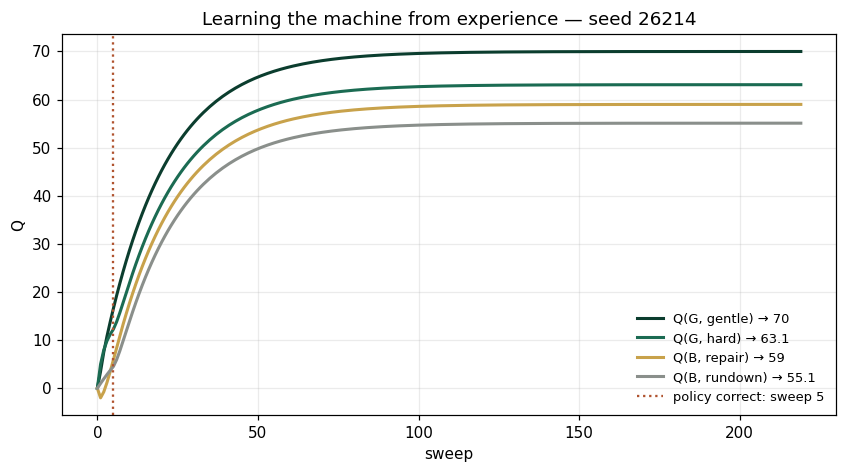

Q at sweep 60: gg=66.8205   max error vs Q*: 3.1795


In [2]:
q, hist, pol_sweep, tol_sweep = q_sweeps()
sw = np.arange(len(hist))
fig, ax = plt.subplots(figsize=(7.8,4.4))
for key, lab, c in (("gg","Q(G, gentle) → 70","#0B3D2E"),("gh","Q(G, hard) → 63.1","#1B6B52"),
                    ("br","Q(B, repair) → 59","#C8A24B"),("bd","Q(B, rundown) → 55.1","#8A8F8B")):
    ax.plot(sw[:220], [h[key] for h in hist[:220]], lw=2, c=c, label=lab)
ax.axvline(pol_sweep, c="#B0532F", ls=":", lw=1.5, label=f"policy correct: sweep {pol_sweep}")
ax.set(xlabel="sweep", ylabel="Q", title="Learning the machine from experience — seed 26214")
ax.legend(frameon=False, fontsize=8.5); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"Q at sweep 60: gg={hist[60]['gg']:.4f}   max error vs Q*: {max(abs(hist[60][a]-QSTAR[a]) for a in QSTAR):.4f}")

## Panel 2 — Policies arrive before values
The Enterprise Policy Improvement Theorem's practical face: the *ordering* of
Q-values stabilizes long before their *levels*. Greedy-vs-Q is already
(gentle, repair) — Chapter 7's optimum — at **sweep 5**, while the values need
**173 sweeps** to land within 0.01. The enterprise reading: an RL system can
be behaviorally right while its internal valuations are still wildly wrong —
which is both why RL deploys early and why its value estimates should never be
read as appraisals.

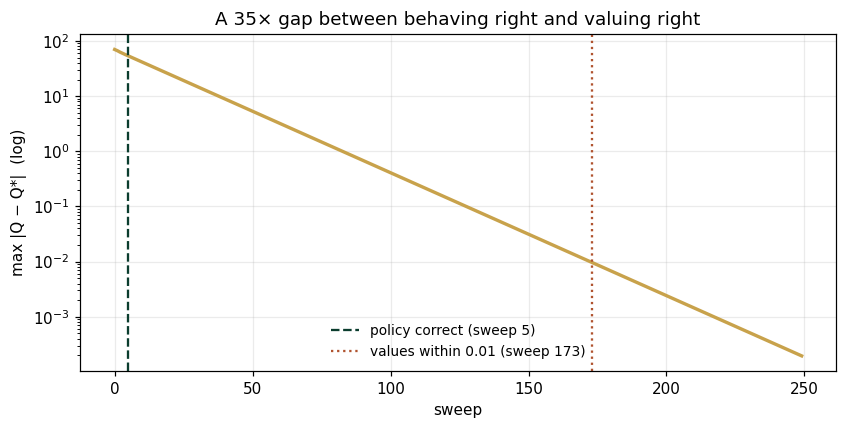

policy correct at sweep 5;  values within 0.01 at sweep 173


In [3]:
errs = [max(abs(h[a]-QSTAR[a]) for a in QSTAR) for h in hist]
fig, ax = plt.subplots(figsize=(7.8,4.0))
ax.semilogy(errs[:250], c="#C8A24B", lw=2.2)
ax.axvline(pol_sweep, c="#0B3D2E", ls="--", lw=1.5, label=f"policy correct (sweep {pol_sweep})")
ax.axvline(tol_sweep, c="#B0532F", ls=":", lw=1.5, label=f"values within 0.01 (sweep {tol_sweep})")
ax.set(xlabel="sweep", ylabel="max |Q − Q*|  (log)", title="A 35× gap between behaving right and valuing right")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"policy correct at sweep {pol_sweep};  values within 0.01 at sweep {tol_sweep}")

## Panel 3 — Knowledge-augmented optimization
The Knowledge-Augmented Optimization Theorem, on a 3×3 vendor–product
assignment. Unconstrained best: 26 (the diagonal). The Enterprise Ontology
(Def.) contributes two rules — vendor 1 cannot serve product 1, vendor 3
cannot serve product 3 — pruning the 6 assignments to **3 feasible**; the
hybrid best is **19**, certified. The naive per-vendor greedy picks the banned
$8$ immediately (**rule violated**): Hybrid AI–Optimization Systems Outperform
Purely Analytical or Purely Data-Driven Systems (Prop.) — the symbolic layer
knows what the scores don't.

In [4]:
rows = assignments()
print("assignment        value  feasible")
for perm, val, feas in rows:
    print(f"v→p {tuple(p+1 for p in perm)}   {val:5d}   {'yes' if feas else 'NO'}")
picks, viol = greedy_naive()
print(f"\nunconstrained best: {max(v for _,v,_ in rows)}   hybrid (feasible) best: {max(v for _,v,f in rows if f)}")
print(f"naive greedy picks: {[(i+1,j+1) for i,j in picks]} — violates ontology: {viol}")

assignment        value  feasible
v→p (1, 2, 3)      26   NO
v→p (1, 3, 2)      20   NO
v→p (2, 1, 3)      20   NO
v→p (2, 3, 1)      19   yes
v→p (3, 1, 2)      14   yes
v→p (3, 2, 1)      19   yes

unconstrained best: 26   hybrid (feasible) best: 19
naive greedy picks: [(1, 1), (2, 2), (3, 3)] — violates ontology: True


## Validation — agrees with `DCT_V2_Ch14_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"Q_gg_star":70.0,"Q_gh_star":63.1,"Q_br_star":59.0,"Q_bd_star":55.1,
 "Q_gg_60":66.8205,"q_err_60":3.1795,"sweep_policy_correct":5,"sweeps_to_q_tol":173,
 "greedy_matches_ch7":1,"n_perms":6,"n_feasible":3,"best_unconstrained":26,
 "best_hybrid":19,"greedy_violates":1}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:22s} {ref[k]}")
print("\nAll checkpoints agree — seed 26214.")

PASS  Q_gg_star              70.0
PASS  Q_gh_star              63.1
PASS  Q_br_star              59.0
PASS  Q_bd_star              55.1
PASS  Q_gg_60                66.8205
PASS  q_err_60               3.1795
PASS  sweep_policy_correct   5
PASS  sweeps_to_q_tol        173
PASS  greedy_matches_ch7     1
PASS  n_perms                6
PASS  n_feasible             3
PASS  best_unconstrained     26
PASS  best_hybrid            19
PASS  greedy_violates        1

All checkpoints agree — seed 26214.


**Next**: Exercises 14.5–14.9 (Part C) vary the learning rate and watch the policy/value gap breathe; AXIOM-14's agent arena runs the learner live against the machine. Chapter 15 assembles everything into digital twins. Solutions: IM Vol. II, Ch. 14.